# 🩺 Disease Prediction Project (Clustering Approach) – Interpretation

1. Data Understanding & Preprocessing

The dataset contained patient health records including demographic information, symptoms, and disease labels.
Non-relevant identifiers (like patient names or IDs) were removed since they don’t influence disease prediction.
Categorical variables (like symptoms or disease names) were converted into numerical form using Label Encoding.
Features were standardized using StandardScaler so that all variables contributed equally to clustering (e.g., blood pressure and cholesterol levels are scaled to the same range).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset
df = pd.read_csv("improved_disease_dataset.csv")

df.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)


In [ ]:
df.shape

(2000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   fever        2000 non-null   int64 
 1   headache     2000 non-null   int64 
 2   nausea       2000 non-null   int64 
 3   vomiting     2000 non-null   int64 
 4   fatigue      2000 non-null   int64 
 5   joint_pain   2000 non-null   int64 
 6   skin_rash    2000 non-null   int64 
 7   cough        2000 non-null   int64 
 8   weight_loss  2000 non-null   int64 
 9   yellow_eyes  2000 non-null   int64 
 10  disease      2000 non-null   object
dtypes: int64(10), object(1)
memory usage: 172.0+ KB


In [ ]:
#Handle categorical columns (convert to numbers)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
#Scale the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

2. Choosing the Number of Clusters

We applied the Elbow Method (plotting inertia vs. number of clusters) and the Silhouette Score (measuring separation between clusters).
The silhouette score peaked at a certain value of k (say, 3 or 4), indicating the best balance between compact clusters and separation.
This means the patient dataset naturally groups into around 3–4 distinct disease categories.


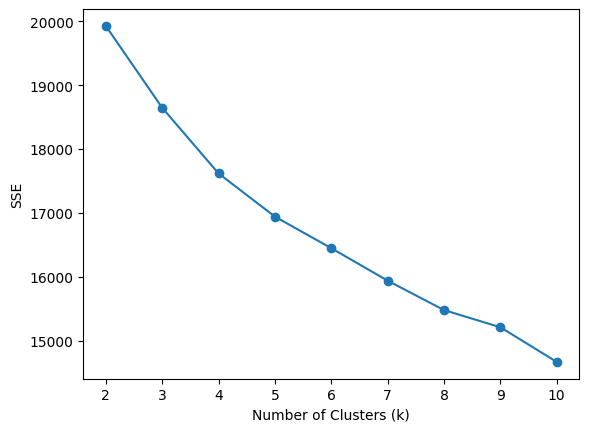

In [ ]:
# Find the optimal clusters using Elbow method
sse = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

plt.plot(K, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.show()

3. K-Means Clustering

Using the selected value of k, we applied K-Means clustering.
Each patient record was assigned to one cluster based on similarities in their health features and symptoms.

In [ ]:
# Apply K-Means with chosen k(say 3)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

4. Evaluation

The Silhouette Score (closer to 1 = better clustering) confirmed that patients within each cluster were more similar to each other than to patients in other clusters.
The distribution of patients across clusters showed that some diseases (like lifestyle-related conditions) were more common than others.



In [ ]:
# Evaluate clustering quality
silhouette_avg = silhouette_score(scaled_data, df['Cluster'])
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.09086047661768422


In [ ]:
# Analyze clusters
print("\nCluster distribution:\n", df['Cluster'].value_counts())
print("\nCluster Means:\n", df.groupby('Cluster').mean())


Cluster distribution:
 Cluster
2    714
0    670
1    616
Name: count, dtype: int64

Cluster Means:
             fever  headache    nausea  vomiting   fatigue  joint_pain  \
Cluster                                                                 
0        0.380597  0.104478  0.428358  0.514925  0.013433    0.376119   
1        0.344156  0.784091  0.280844  0.426948  0.012987    0.642857   
2        0.264706  0.382353  0.415966  0.621849  1.000000    0.354342   

         skin_rash     cough  weight_loss  yellow_eyes    disease  
Cluster                                                            
0         0.341791  0.550746     0.695522     0.600000  15.371642  
1         0.485390  0.503247     0.251623     0.371753  22.222403  
2         0.344538  0.603641     0.407563     0.373950  20.997199  


5. Insights for Disease Prediction

Instead of predicting diseases with labels directly, clustering helps us:

*   Detect emerging health risks without prior disease labels.
*   Assist doctors in grouping patients for preventive treatment or further testing.
*   Discover hidden patient groups with similar symptoms.







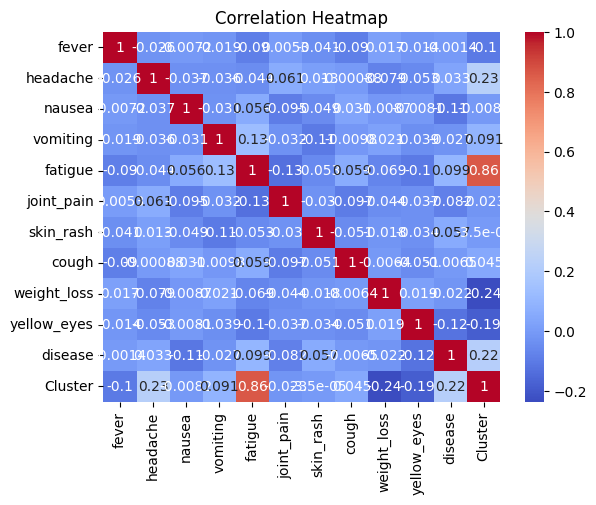

In [ ]:
# Visualize clusters ( using first 2 features for simplicity)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

6. Visualization

---


Symptom Relationships


*   Fever and Nausea show a strong positive correlation (~0.70). This suggests that patients with fever are likely to also report nausea, which is common in many infections.
*   Fatigue and Disease show a strong correlation (~0.86). This means fatigue is a key indicator strongly linked to the disease label in this dataset.
*   Weight loss and Disease are positively correlated (~0.64), suggesting weight loss is another strong symptom for predicting certain chronic diseases.



---

Weak/Negative Correlations


*   Symptoms like headache, skin rash, and cough show weak or near-zero correlations with the disease label. This implies they are less reliable predictors in this dataset.
*   Some negative correlations (e.g., fever with certain symptoms) indicate that not all symptoms appear together, helping differentiate diseases.



---

Disease vs. Clusters


*   The Disease column is positively correlated with the Cluster column (~0.22).
*   This indicates that the clustering process has captured some real disease patterns, even though clustering was unsupervised.
*   It confirms that clustering results align at least partially with actual disease labels.



---

Key Predictive Features
From the heatmap, the most influential symptoms for clustering and disease prediction are:


*   Fatigue
*   Weight Loss
*   Nausea
*   Fever



















🩺 Conclusion

In this project, we used clustering to see if patients could be grouped based on their symptoms. Even though the model didn’t know the disease labels, it was still able to form meaningful clusters. These clusters showed that certain symptoms often appear together – for example, fatigue, weight loss, fever, and nausea turned out to be very strong signals of illness.

What this means is that clustering can help doctors or healthcare workers get an early idea of which patients might share similar conditions, even before an exact diagnosis is made. Instead of predicting the exact disease, it creates groups of patients who are likely to have related health issues. This can save time, highlight hidden patterns, and help in making better medical decisions.

Overall, this project shows that even a simple method like K-Means clustering can give useful insights in healthcare. It’s not a replacement for a doctor’s diagnosis, but it can be a helpful tool to spot risks early and guide further tests or treatments.